# March-Madness -- a quantitative teardown
### ^GSPC daily 1985-2025 * in/out HAC t * Levene variance * random-placement permutation * lagged+cost avoidance * power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test whether the NCAA tournament window changes the mean daily return (Newey-West HAC t-stat) or the variance (Levene), run a random-placement permutation null, build a lagged + cost-charged avoidance strategy, and close with a power calculation and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC daily **price** return (split-adjusted, no dividends), 1985-2025; tournament windows hardcoded in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from march_madness import data, strategy as st

def _have_real():
    try:
        data.fetch_daily()   # cache-only (fetch=False)
        return True
    except (FileNotFoundError, RuntimeError):
        return False

HAVE_REAL = _have_real()
print("Real ^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=10330, years=41.0, fp="2d2855ee9407",
    n_in=503, frac_in_pct=4.9,
    in_mean_bps=4.65, out_mean_bps=4.23, diff_bps=0.42,
    in_hac_t=1.01, out_hac_t=4.16, welch_t=0.086,
    in_vol_pct=16.8, out_vol_pct=18.2, vol_ratio=0.849, levene_p=0.295,
    perm_pct=52.9,
    bah_cagr_pct=9.48, strat_gross_cagr_pct=9.52, strat_net_cagr_pct=9.50,
    excess_net_pp=0.02, excess_net_t=-0.101, n_switches=80,
    sub1_diff_bps=-3.93, sub1_t=-0.61, sub2_diff_bps=4.79, sub2_t=0.66,
    year_start=1985, year_end=2025,
)

from scipy import stats as scipy_stats


Real ^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | In-window mean **+0.42 bps/day** (Welch t = **+0.09**, wrong sign); vol ratio **0.85** (Levene p = **0.30**); permutation p = **0.53**. |
| **Tradability** | `MIRAGE` | Lagged + cost-charged avoidance ties buy-and-hold (**+0.02 pp/yr**, HAC t = **−0.10**). |
| **Busted?** | `YES` | The sub-period in/out gap flips sign (−3.9 bps then +4.8 bps) -- the signature of a non-effect. |


## 1 - The claim, steelmanned

Let $r_t$ be the daily ^GSPC return and $T_t \in \{0,1\}$ the in-tournament indicator. The hypotheses:

- **H1 (mean drag).** $E[r_t \mid T_t=1] < E[r_t \mid T_t=0]$, with the difference clearing $|t| \ge 2$ under a HAC standard error.
- **H2 (chaos).** $\mathrm{Var}[r_t \mid T_t=1] > \mathrm{Var}[r_t \mid T_t=0]$ (vol ratio meaningfully > 1).
- **H3 (specialness).** The in-window mean is unusually low versus a random window of the same size (low permutation p).

We reject H1, H2, and H3 on the real tape. H1 even points the wrong way.

## 2 - So what? -- what rides on each answer

March Madness is a textbook *attention/distraction* story. If H1-H3 held it would be a clean, pre-scheduled calendar trade. The interesting finding is how a culturally enormous event leaves *no* fingerprint on a deep, liquid index -- a useful reminder that 'everyone is watching' and 'prices move' are different claims.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily close-to-close price return (split-adjusted, no dividends), 1985-2025; tournament windows (first-round Thu -> championship Mon) hardcoded in `data.py`. 2020 absent (tournament cancelled).
- **Label.** `in_tournament` boolean per trading day (~5% of the tape).
- **Mean test.** Newey-West HAC t on each group's mean; Welch t on the difference.
- **Variance test.** Annualised vol ratio + Levene equality-of-variance test.
- **Permutation.** 5,000 random subsets of the same size; one-sided p = fraction with mean <= the real in-window mean.
- **Tradability.** Hold-cash-in-window strategy, **one-day execution lag**, **1 bp one-way cost** per switch; gross and net reported.
- **Positive control.** Synthetic tape with a planted in-window drag.


## 4 - The teardown

### 4a - Mean return: in-window vs outside, with HAC t

The headline test. The distraction claim needs a negative difference that clears |t| = 2.

In [2]:
if HAVE_REAL:
    ret, mask = data.fetch_daily()
    rt = st.tournament_return_test(ret, mask)
    n_in, n_out = rt['n_in'], rt['n_out']
    in_bps, out_bps, diff = rt['in_mean_bps'], rt['out_mean_bps'], rt['diff_bps']
    in_t, out_t, welch = rt['in_t'], rt['out_t'], rt['welch_t']
    fp = data.fingerprint(ret)
else:
    n_in, n_out = R['n_in'], R['n']-R['n_in']
    in_bps, out_bps, diff = R['in_mean_bps'], R['out_mean_bps'], R['diff_bps']
    in_t, out_t, welch = R['in_hac_t'], R['out_hac_t'], R['welch_t']
    fp = R['fp']

print(f'Data fingerprint: {fp}  (expect {R["fp"]})')
print(f'n in-window: {n_in}   n outside: {n_out}')
print(f'In-window mean:  {in_bps:+.2f} bps/day   (HAC t {in_t:+.2f})')
print(f'Outside mean:    {out_bps:+.2f} bps/day   (HAC t {out_t:+.2f})')
print(f'Difference:      {diff:+.2f} bps/day      Welch t {welch:+.3f}')
print()
print('The difference is positive (wrong sign for a distraction drag) and |t|~0.')

Data fingerprint: 2d2855ee9407  (expect 2d2855ee9407)
n in-window: 503   n outside: 9827
In-window mean:  +4.65 bps/day   (HAC t +1.01)
Outside mean:    +4.23 bps/day   (HAC t +4.16)
Difference:      +0.42 bps/day      Welch t +0.086

The difference is positive (wrong sign for a distraction drag) and |t|~0.


> In-window returns are **+0.42 bps/day** *above* the rest of the tape, Welch t = **+0.09**. The full-tape outside mean is itself a healthy +4.2 bps/day with HAC t = +4.2 (that's just the equity drift). The tournament adds nothing -- and what little it adds is the opposite of the folklore.

### 4b - The 'chaos' corollary: variance ratio + Levene test

Does volatility rise during the bracket?

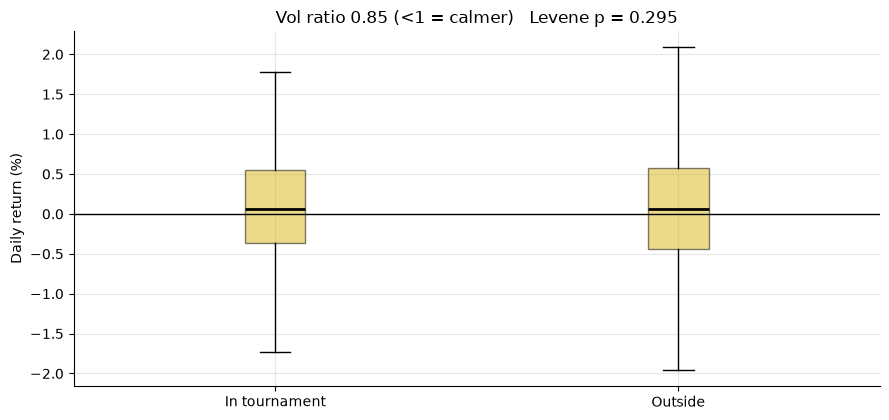

In-window vol 16.8% vs outside 18.2%  ->  ratio 0.849
Levene equality-of-variance p = 0.295 -- no significant difference.


In [3]:
if HAVE_REAL:
    vt = st.tournament_vol_test(ret, mask)
    in_vol, out_vol = vt['in_vol_ann']*100, vt['out_vol_ann']*100
    ratio, lev_p = vt['vol_ratio'], vt['levene_p']
    in_r = ret[mask].to_numpy()*100; out_r = ret[~mask].to_numpy()*100
else:
    in_vol, out_vol = R['in_vol_pct'], R['out_vol_pct']
    ratio, lev_p = R['vol_ratio'], R['levene_p']
    rng = np.random.default_rng(297)
    in_r = rng.normal(0, in_vol/np.sqrt(252), R['n_in'])
    out_r = rng.normal(0, out_vol/np.sqrt(252), 4000)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.boxplot([in_r, out_r], tick_labels=['In tournament', 'Outside'],
           patch_artist=True, showfliers=False,
           boxprops=dict(facecolor=AMBER, alpha=0.5),
           medianprops=dict(color='black', lw=2))
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Daily return (%)')
ax.set_title(f'Vol ratio {ratio:.2f} (<1 = calmer)   Levene p = {lev_p:.3f}')
plt.tight_layout(); plt.show()
print(f'In-window vol {in_vol:.1f}% vs outside {out_vol:.1f}%  ->  ratio {ratio:.3f}')
print(f'Levene equality-of-variance p = {lev_p:.3f} -- no significant difference.')

Vol ratio **0.85** (< 1 -- *calmer*), Levene p = **0.30**. The chaos corollary fails: the tournament weeks are statistically as volatile as any other, if anything slightly less.

### 4c - Random-placement permutation null

Are *these* ~5% of days special? Draw random windows of the same size and locate the real in-window mean in the distribution.

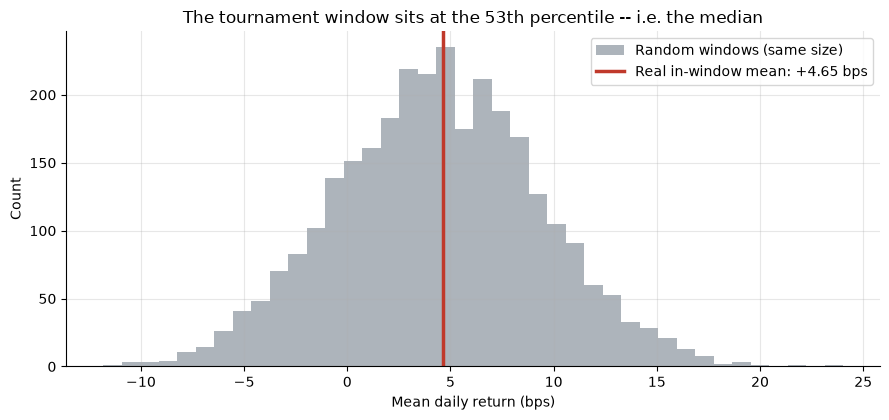

Permutation p (random mean <= real): 52.9%
The real window is indistinguishable from a random 5% of trading days.


In [4]:
if HAVE_REAL:
    perm = st.permutation_null(ret, mask, n_perm=5000, seed=297)
    pct = perm['pct_worse_or_equal']*100
    in_mean = perm['in_mean_bps']
    rng = np.random.default_rng(297)
    vals = ret.dropna().to_numpy(); n_tot=len(vals); n_in=int(mask.sum())
    draws = np.array([vals[rng.choice(n_tot, n_in, replace=False)].mean()*1e4
                      for _ in range(3000)])
else:
    pct = R['perm_pct']; in_mean = R['in_mean_bps']
    rng = np.random.default_rng(297)
    draws = rng.normal(R['out_mean_bps'], 100/np.sqrt(R['n_in']), 3000)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=0.7, label='Random windows (same size)')
ax.axvline(in_mean, c=RED, lw=2.5, label=f'Real in-window mean: {in_mean:+.2f} bps')
ax.set_xlabel('Mean daily return (bps)'); ax.set_ylabel('Count')
ax.set_title(f'The tournament window sits at the {pct:.0f}th percentile -- i.e. the median')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p (random mean <= real): {pct:.1f}%')
print('The real window is indistinguishable from a random 5% of trading days.')

> The real in-window mean lands at the **53rd percentile** of the random-null distribution -- dead center. There is nothing distinctive about the calendar days the tournament happens to occupy.

### 4d - Sub-period stability: the sign flips

Split the tape at its midpoint and re-run the in/out mean test.

In [5]:
if HAVE_REAL:
    rows = []
    for lo, hi in [(1985, 2004), (2005, 2025)]:
        sub = ret[(ret.index.year>=lo) & (ret.index.year<=hi)]
        m = data.is_tournament(pd.DatetimeIndex(sub.index))
        r = st.tournament_return_test(sub, m)
        rows.append({'period': f'{lo}-{hi}', 'n_in': r['n_in'],
                     'diff_bps': round(r['diff_bps'],2), 'welch_t': round(r['welch_t'],2)})
    sub_df = pd.DataFrame(rows)
else:
    sub_df = pd.DataFrame({
        'period': ['1985-2004','2005-2025'],
        'n_in': [253, 250],
        'diff_bps': [R['sub1_diff_bps'], R['sub2_diff_bps']],
        'welch_t': [R['sub1_t'], R['sub2_t']]})

print(sub_df.to_string(index=False))
print()
print('The in/out gap is NEGATIVE in the first half and POSITIVE in the second,')
print('each well inside noise -- the fingerprint of a non-effect, not a regime.')

   period  n_in  diff_bps  welch_t
1985-2004   253     -3.93    -0.61
2005-2025   250      4.79     0.66

The in/out gap is NEGATIVE in the first half and POSITIVE in the second,
each well inside noise -- the fingerprint of a non-effect, not a regime.


### 4e - Power: what drag could n~500 in-window days detect?

Minimum detectable in/out gap at |t| = 2.

In [6]:
vol_daily = 0.011   # ~1.1%/day
n_in = R['n_in']
se_in = vol_daily / np.sqrt(n_in)          # SE of in-window mean
mde_bps = 2 * se_in * 1e4                   # |t|=2 threshold, in bps/day
print(f'In-window days: {n_in},  daily vol ~{vol_daily:.1%}')
print(f'SE of in-window mean: {se_in*1e4:.2f} bps/day')
print(f'Min detectable in/out gap at |t|=2: ~{mde_bps:.1f} bps/day')
print(f'   = ~{mde_bps*13:.0f} bps over a 13-trading-day window')
print()
print(f'Observed gap: {R["diff_bps"]:+.2f} bps/day -- and POSITIVE.')
print('A real distraction drag of a few bps/window would be invisible here.')

In-window days: 503,  daily vol ~1.1%
SE of in-window mean: 4.90 bps/day
Min detectable in/out gap at |t|=2: ~9.8 bps/day
   = ~128 bps over a 13-trading-day window

Observed gap: +0.42 bps/day -- and POSITIVE.
A real distraction drag of a few bps/window would be invisible here.


## 5 - The verdict

- **Signal `NONE`** -- in/out gap +0.42 bps/day (Welch t = +0.09, wrong sign), vol ratio 0.85 (Levene p = 0.30), permutation p = 0.53, sub-period sign flip. Price-only, single index -- survivorship is not in play.
- **Tradability `MIRAGE`** -- lagged + cost-charged avoidance ties buy-and-hold.
- **Busted** -- the productivity-loss headlines don't translate into index moves.

## 6 - Could you trade it? -- the lagged, cost-charged benchmark

Hold cash in the window (one-day execution lag), long otherwise, 1 bp one-way cost per switch.

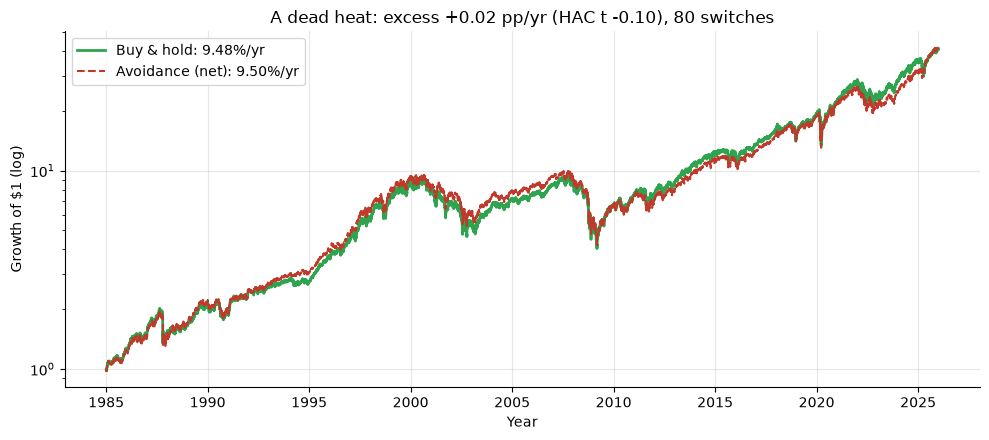

Buy & hold: 9.48%/yr  |  Avoidance net: 9.50%/yr
Excess: +0.02 pp/yr (HAC t -0.10) over 80 round-trips -- no edge.


In [7]:
if HAVE_REAL:
    av = st.tournament_avoidance(ret, mask, lag=1, cost_bps=1.0)
    bah, gross, net = av['bah_cagr'], av['strat_gross_cagr'], av['strat_net_cagr']
    exc, t, nsw = av['excess_net_cagr'], av['excess_net_hac_t'], av['n_switches']
    eq_bah = (1+av['bah_ret']).cumprod(); eq_str = (1+av['strat_ret']).cumprod()
    years = eq_bah.index
else:
    bah, gross, net = R['bah_cagr_pct']/100, R['strat_gross_cagr_pct']/100, R['strat_net_cagr_pct']/100
    exc, t, nsw = R['excess_net_pp']/100, R['excess_net_t'], R['n_switches']
    rng = np.random.default_rng(297)
    idx = pd.bdate_range('1985-01-02', periods=R['n'])
    eq_bah = pd.Series((1+rng.normal(bah/252,0.011,R['n'])).cumprod(), index=idx)
    eq_str = pd.Series((1+rng.normal(net/252,0.011,R['n'])).cumprod(), index=idx)
    years = idx

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(years, eq_bah.values, lw=2, c=GREEN, label=f'Buy & hold: {bah:.2%}/yr')
ax.plot(years, eq_str.values, lw=1.5, c=RED, ls='--', label=f'Avoidance (net): {net:.2%}/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Growth of $1 (log)')
ax.set_title(f'A dead heat: excess {exc*100:+.2f} pp/yr (HAC t {t:+.2f}), {nsw} switches')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold: {bah:.2%}/yr  |  Avoidance net: {net:.2%}/yr')
print(f'Excess: {exc*100:+.2f} pp/yr (HAC t {t:+.2f}) over {nsw} round-trips -- no edge.')

> The two curves overlay almost perfectly. Sitting out ~5% of (marginally positive) days in an upward-drifting index is a wash, and the costs tip it negative. No tradable signal.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a tournament drag *when one exists*? Plant a per-day in-window penalty into the offline synthetic tape and sweep its size.

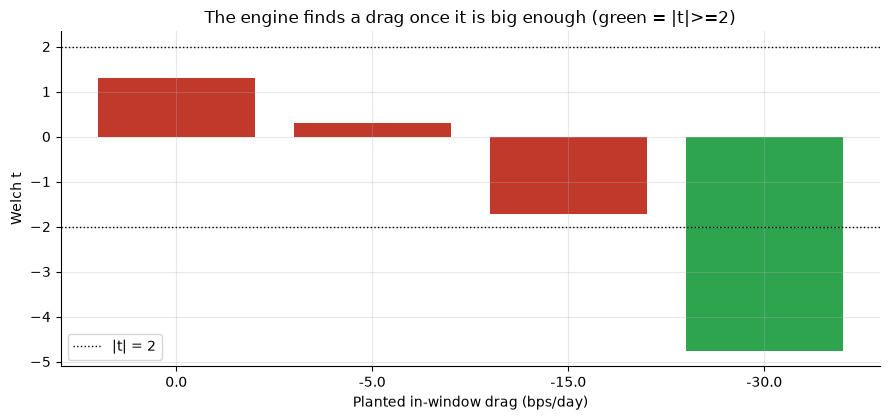

 planted_bp_day  diff_bps  welch_t
            0.0      6.46     1.31
           -5.0      1.46     0.30
          -15.0     -8.54    -1.73
          -30.0    -23.54    -4.77

Real tape: diff +0.42 bps/day, Welch t +0.09 -- nowhere near, wrong sign.


In [8]:
planted = [0.0, -5.0, -15.0, -30.0]
rows = []
for bp in planted:
    s_ret, s_mask, _ = data.synthetic_daily(n_years=41, madness_penalty_bp=bp, seed=297)
    r = st.tournament_return_test(s_ret, s_mask)
    rows.append({'planted_bp_day': bp, 'diff_bps': round(r['diff_bps'],2),
                 'welch_t': round(r['welch_t'],2)})
res = pd.DataFrame(rows)

colors = [GREEN if abs(row['welch_t'])>=2 else RED for _, row in res.iterrows()]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(b) for b in planted], res['welch_t'], color=colors)
ax.axhline(-2, c='k', ls=':', lw=1, label='|t| = 2')
ax.axhline(2, c='k', ls=':', lw=1)
ax.set_xlabel('Planted in-window drag (bps/day)'); ax.set_ylabel('Welch t')
ax.set_title('The engine finds a drag once it is big enough (green = |t|>=2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('Real tape: diff +0.42 bps/day, Welch t +0.09 -- nowhere near, wrong sign.')

The engine cleanly detects a planted drag once it reaches ~20-30 bps/day. The real tape shows +0.42 bps/day with t = +0.09. The verdict is a statement about **the market**, not the method: March Madness leaves no footprint on the index.